# ELO LASSO Regression

In [164]:
# load libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import sys
from scipy import stats


from sklearn.metrics import mean_squared_error, log_loss, confusion_matrix, accuracy_score, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_predict, cross_val_score
from sklearn.calibration import CalibratedClassifierCV, calibration_curve


from elo_grad import EloEstimator, Regressor
from elo_grad.sklearn import SKEloEstimator

print(f'Python {sys.version} on {sys.platform}.')


Python 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:19:24) [Clang 18.1.8 ] on darwin.


In [165]:
def evaluate_model(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred)
    
    print("Confusion Matrix:\n", cm)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC-ROC: {auc:.4f}")
    
    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2)
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.show()

In [140]:
# import data
train_set = pl.read_csv("../data/processed/train_set.csv", try_parse_dates=True)
#train_set['date_game'] = pd.to_datetime(train_set['date_game'])

train_set = train_set.with_columns((24 * 60 * 60 * pl.col('date_game').cast(pl.Int64)).alias('t'))



In [142]:
train_set = train_set.with_columns(
    (pl.col('pts_main') > pl.col('pts_opp')).cast(pl.Int8).alias('result')
)
train_set.head()

# Create dummy variables
# dummy_cols = pd.get_dummies(train_set['wl_main'])
# train_set['wl_main'] = dummy_cols['W'].astype(int)



date_game,game_id,team_id_main,team_abbreviation_main,team_wins_losses_main,pts_main,matchup_main,wl_main,fgm_main,fga_main,fg_pct_main,fg3m_main,fg3a_main,fg3_pct_main,ftm_main,fta_main,ft_pct_main,oreb_main,dreb_main,ast_main,stl_main,blk_main,tov_main,pf_main,plus_minus_main,team_id_opp,team_abbreviation_opp,team_wins_losses_opp,pts_opp,team_name_opp,matchup_opp,wl_opp,fgm_opp,fga_opp,fg_pct_opp,fg3m_opp,fg3a_opp,fg3_pct_opp,ftm_opp,fta_opp,ft_pct_opp,oreb_opp,dreb_opp,reb_opp,ast_opp,stl_opp,blk_opp,tov_opp,pf_opp,plus_minus_opp,season_id,is_playoffs,elo_main_pre_538,elo_main_post_538,win_equiv,elo_opp_pre_538,elo_opp_post_538,game_result,forecast,t,result
date,i64,i64,str,str,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,str,f64,i64,i8
1981-05-05,48000048,1610612738,"""BOS""","""1-0""",98.0,"""BOS vs. HOU""","""W""",41.0,95.0,0.432,0.0,1.0,0.0,16.0,20.0,0.8,25.0,29.0,23.0,6.0,5.0,19.0,21.0,3,1610612745,"""HOU""","""0-1""",95.0,"""Houston Rockets""","""HOU @ BOS""","""L""",42.0,99.0,0.424,0.0,2.0,0.0,11.0,14.0,0.786,19.0,23.0,42.0,23.0,15.0,3.0,10.0,20.0,-3,41980,1,1667.918,1670.298,58.218166,1573.3342,1570.9542,"""W""",0.75401,357868800,1
1981-05-05,48000048,1610612745,"""HOU""","""0-1""",95.0,"""HOU @ BOS""","""L""",42.0,99.0,0.424,0.0,2.0,0.0,11.0,14.0,0.786,19.0,23.0,23.0,15.0,3.0,10.0,20.0,-3,1610612738,"""BOS""","""1-0""",98.0,"""Boston Celtics""","""BOS vs. HOU""","""W""",41.0,95.0,0.432,0.0,1.0,0.0,16.0,20.0,0.8,25.0,29.0,54.0,23.0,6.0,5.0,19.0,21.0,3,41980,1,1573.3342,1570.9542,48.834915,1667.918,1670.298,"""L""",0.24599,357868800,0
1981-05-07,48000049,1610612738,"""BOS""","""1-1""",90.0,"""HOU @ BOS""","""W""",34.0,85.0,0.4,2.0,2.0,1.0,22.0,32.0,0.688,13.0,22.0,16.0,6.0,8.0,9.0,17.0,2,1610612745,"""HOU""","""1-1""",92.0,"""Boston Celtics""","""BOS vs. HOU""","""L""",41.0,82.0,0.5,0.0,3.0,0.0,8.0,13.0,0.615,14.0,34.0,48.0,17.0,6.0,7.0,22.0,27.0,-2,41980,1,1670.298,1661.5709,57.457176,1570.9542,1579.6813,"""L""",0.759057,358041600,0
1981-05-07,48000049,1610612745,"""HOU""","""1-1""",92.0,"""BOS vs. HOU""","""L""",41.0,82.0,0.5,0.0,3.0,0.0,8.0,13.0,0.615,14.0,34.0,17.0,6.0,7.0,22.0,27.0,-2,1610612738,"""BOS""","""1-1""",90.0,"""Houston Rockets""","""HOU @ BOS""","""W""",34.0,85.0,0.4,2.0,2.0,1.0,22.0,32.0,0.688,13.0,22.0,35.0,16.0,6.0,8.0,9.0,17.0,2,41980,1,1570.9542,1579.6813,49.71302,1670.298,1661.5709,"""W""",0.240943,358041600,1
1981-05-09,48000050,1610612738,"""BOS""","""2-1""",94.0,"""HOU vs. BOS""","""L""",24.0,79.0,0.304,0.0,1.0,0.0,23.0,31.0,0.742,19.0,29.0,10.0,6.0,9.0,21.0,19.0,-23,1610612745,"""HOU""","""1-2""",71.0,"""Boston Celtics""","""BOS @ HOU""","""W""",40.0,89.0,0.449,2.0,3.0,0.667,12.0,19.0,0.632,16.0,28.0,44.0,24.0,12.0,7.0,11.0,25.0,23,41980,1,1661.5709,1680.8596,59.120193,1579.6813,1560.3926,"""W""",0.4739607,358214400,1


In [143]:
scaled_predictors = ['fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 
       'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'pts_main',
       'plus_minus_main'] 

train_set[scaled_predictors] = stats.zscore(train_set[scaled_predictors])

all_predictors = ['fgm_main', 'fga_main', 'fg_pct_main',
       'fg3m_main', 'fg3a_main', 'fg3_pct_main', 'ftm_main', 'fta_main',
       'ft_pct_main', 'oreb_main', 'dreb_main', 
       'ast_main',
       'stl_main', 'blk_main', 'tov_main', 'pf_main', 'pts_main',
       'plus_minus_main', 'is_playoffs'] 


In [ ]:
# Fit Elo regression
estimator = EloEstimator(
    k_factor=20, 
    beta=200,
    default_init_rating=1505,
    entity_cols=("team_abbreviation_main", "team_abbreviation_opp"),
    score_col="result",
    date_col="t",
    track_rating_history=True,
    # Set k-factor/step-size to 1 for the home advantage regressor
    additional_regressors=[Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=0.4) for p in all_predictors]
)
# Get expected scores
expected_scores = estimator.predict_proba(train_set)
# Get final ratings (of form (timestamp, rating)) for home advantage
ratings = estimator.model.ratings

## Get predictions and ratings

In [145]:
# Fit the estimator
model_fit = estimator.fit(train_set)

# Get predictions
preds = estimator.predict(train_set)

In [146]:
sorted(estimator.model.ratings.items(), key=lambda item: item[1][1], reverse=True)[:10]


[('SAS', (1193961600, 1758.337974606847)),
 ('DAL', (1193875200, 1756.1325170421437)),
 ('PHO', (1117670400, 1702.7857876016055)),
 ('DET', (1193961600, 1687.354913032224)),
 ('HOU', (1193961600, 1623.8815341441928)),
 ('UTA', (1193961600, 1620.1636564581079)),
 ('CHI', (1193875200, 1619.5708268762664)),
 ('NJN', (1193961600, 1610.9768876303035)),
 ('CLE', (1193875200, 1594.3342753464758)),
 ('CHH', (1035849600, 1579.022018099703))]

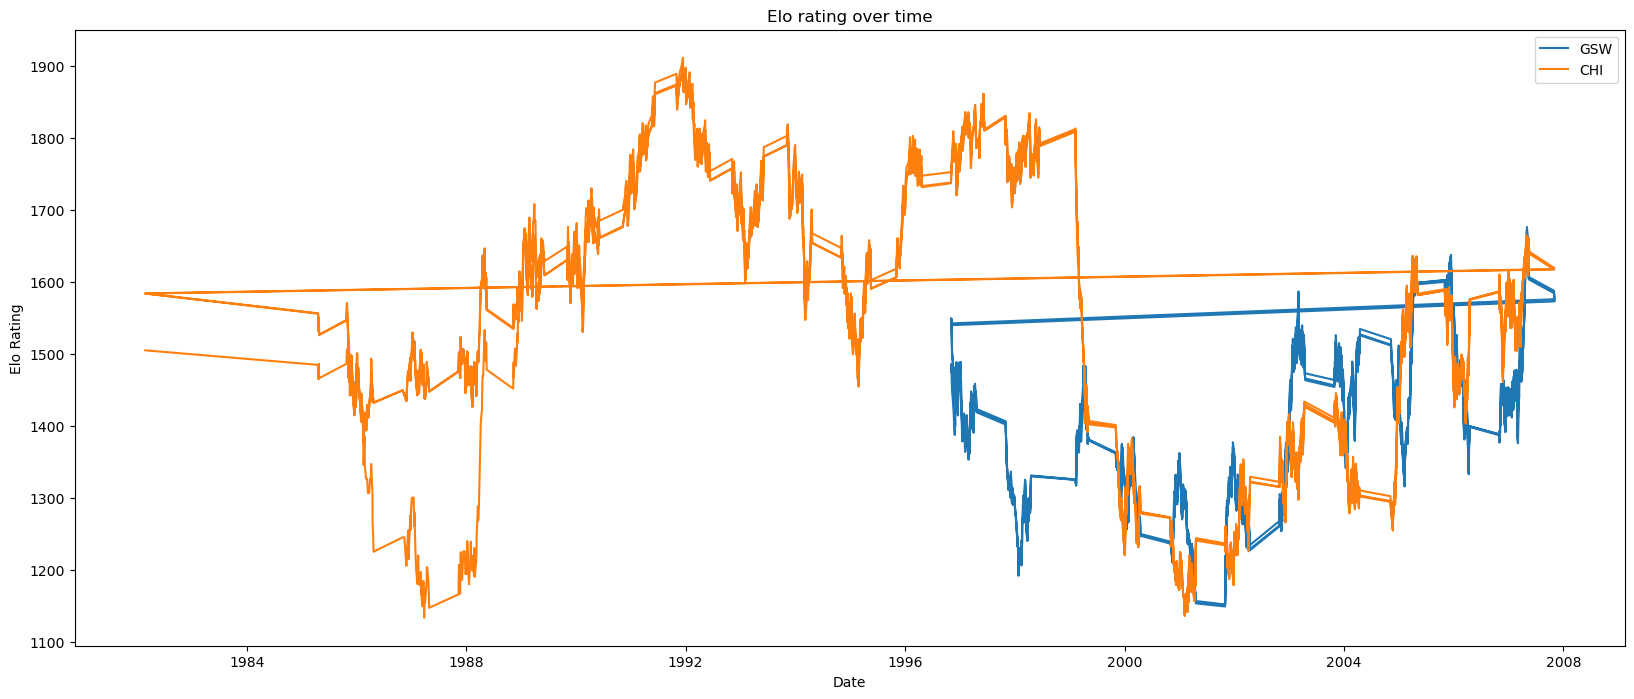

In [147]:
fig, ax = plt.subplots(figsize=(20, 8))
estimator.plot(['GSW', 'CHI'], ax=ax)
plt.show()

## Evaluate the predictions

In [148]:
y_val_pred = estimator.predict_proba(train_set)[:, 1]
print(f"Test set log-loss: {log_loss(train_set['result'], y_val_pred):.4f}")

Test set log-loss: 0.6363


In [149]:
confusion_matrix(train_set['result'], y_val_pred.round())

array([[11166,  6113],
       [ 6124, 11151]])

### Check the calibration

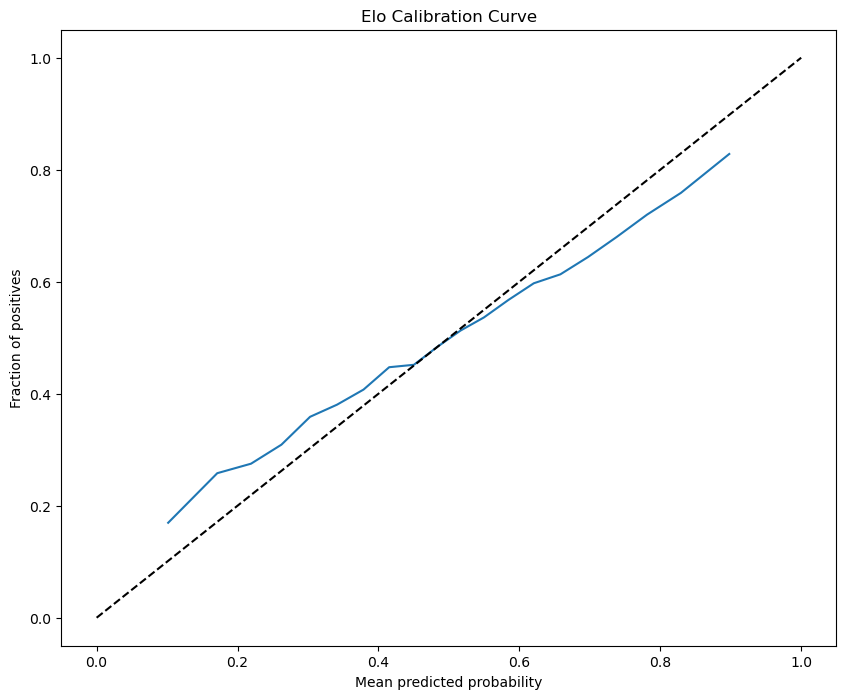

In [150]:
prob_true, prob_pred = calibration_curve(train_set['result'], y_val_pred, n_bins=20, strategy='quantile')

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(prob_pred, prob_true)
ax.plot([0, 1], [0, 1], color='black', linestyle='--')
ax.set(
    title='Elo Calibration Curve',
    xlabel='Mean predicted probability',
    ylabel='Fraction of positives',
)

plt.show()


### Grid search

In [158]:
gs = GridSearchCV(
    estimator=SKEloEstimator(entity_cols=('team_abbreviation_main', 'team_abbreviation_opp'), score_col='result'), 
    param_grid={
        'beta': [200],
        'k_factor': [20],
        'additional_regressors': [Regressor(name=p, k_factor=1, penalty="l1", lambda_reg=[0.1,0.2,0.3,0.4,0.5]) for p in all_predictors]
                },
    cv=TimeSeriesSplit(n_splits=5),
)


In [159]:
gs.fit(train_set[all_predictors], train_set['result'])
pl.DataFrame(gs.cv_results_).sort('mean_test_score', descending=False)

TypeError: 'Regressor' object is not iterable

### Comparing the log loss with and without the regressors

In [ ]:
y_val_pred_home = elo_home.predict_proba(X_val)[:, 1]
print(f"Validation set log-loss: {log_loss(X_val['result'], y_val_pred_home):.4f}")

We can also visualise the home advantage effect over time.



In [ ]:
fig, ax = plt.subplots(figsize=(20, 8))
elo_home.plot(['home'], ax=ax)
plt.show()

Confusion Matrix:
 [[11166  6113]
 [ 6124 11151]]
Accuracy: 0.6459
Precision: 0.6459
Recall: 0.6455
F1-Score: 0.6457
AUC-ROC: 0.6459


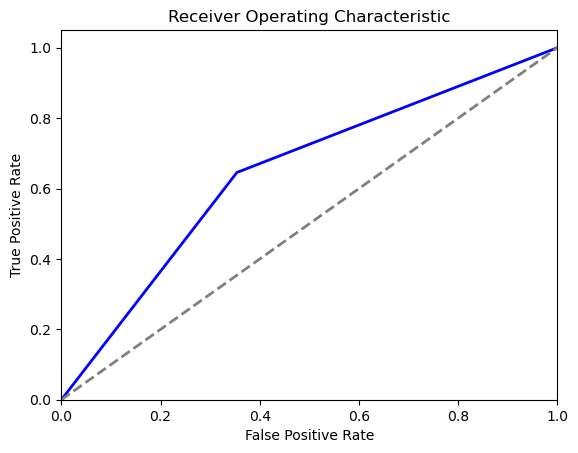

In [168]:
evaluate_model(train_set['result'], y_val_pred.round())